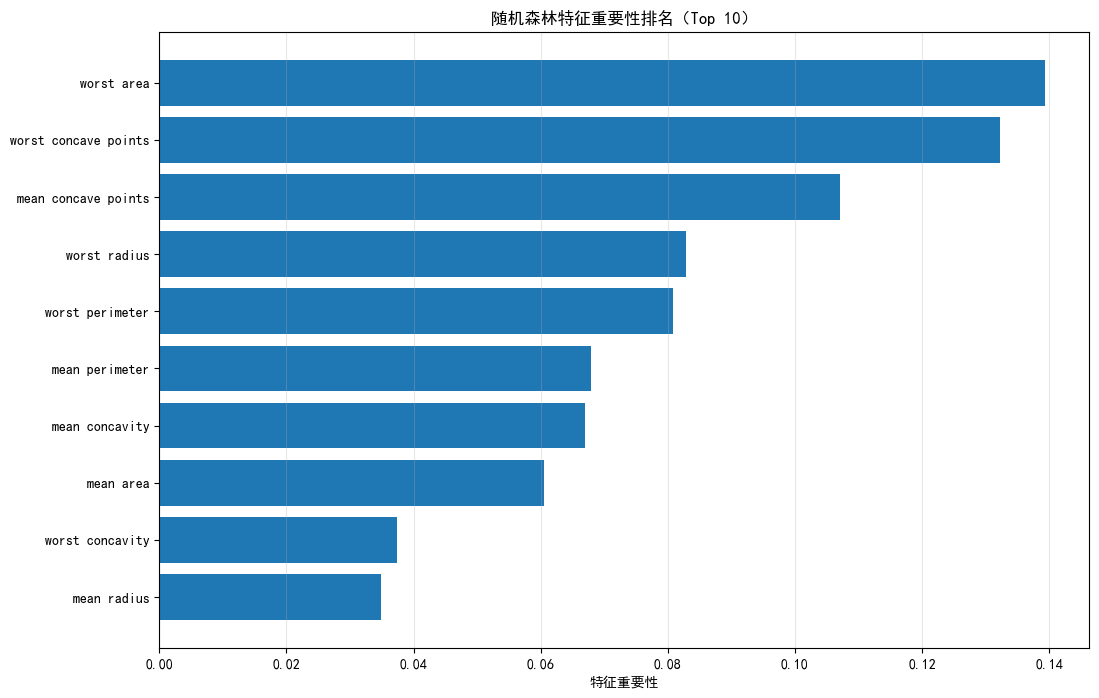

随机森林的集体决策机制：
1. 每棵树基于不同的数据子集和特征子集训练
2. 最终决策通过投票或平均得出
3. 降低了过拟合风险，提高了泛化能力


In [3]:
# %load 6-5.py
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # ÉèÖÃÄ¬ÈÏ×ÖÌåÎªºÚÌå
plt.rcParams['axes.unicode_minus'] = False
from sklearn.datasets import make_circles
from sklearn.svm import SVC
def svm_kernel_trick_demo():
    """
    SVMºË¼¼ÇÉÑÝÊ¾£ºÊ¹ÓÃ¸ßË¹ºË´¦Àí·ÇÏßÐÔ¿É·ÖÊý¾Ý
    """
    # Éú³É·ÇÏßÐÔ¿É·ÖÊý¾Ý£¨»·ÐÎÊý¾Ý£©
    X, y = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)
    # ÑµÁ·Ê¹ÓÃ¸ßË¹ºËµÄSVM
    svm_rbf = SVC(kernel='rbf', gamma=10)
    svm_rbf.fit(X, y)
    # »æÖÆ¾ö²ß±ß½ç
    plt.figure(figsize=(10, 6))
    
    # ´´½¨Íø¸ñµã
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Ô¤²âÍø¸ñµãµÄÀà±ð
    Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # »æÖÆ¾ö²ß±ß½çºÍÊý¾Ýµã
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k')
    
    plt.xlabel('ÌØÕ÷1')
    plt.ylabel('ÌØÕ÷2')
    plt.title('SVMºË¼¼ÇÉ£º¸ßË¹ºË´¦Àí·ÇÏßÐÔ¿É·ÖÊý¾Ý')
    plt.show()
    return svm_rbf

def random_forest_insights():
    """
    Ì½Ë÷Ëæ»úÉ­ÁÖµÄ¾ö²ß»úÖÆ
    """
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.datasets import load_breast_cancer
    import pandas as pd
    
    # ¼ÓÔØÍþË¹¿µÐÇÈéÏÙ°©Êý¾Ý¼¯
    cancer = load_breast_cancer()
    X, y = cancer.data, cancer.target
    feature_names = cancer.feature_names
    
    # ÑµÁ·Ëæ»úÉ­ÁÖ
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # ÌØÕ÷ÖØÒªÐÔ·ÖÎö
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # ¿ÉÊÓ»¯ÌØÕ÷ÖØÒªÐÔ
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['feature'][:10], 
             feature_importance['importance'][:10])
    plt.xlabel('特征重要性')
    plt.title('随机森林特征重要性排名（Top 10）')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.show()
    
    print("随机森林的集体决策机制：")
    print("1. 每棵树基于不同的数据子集和特征子集训练")
    print("2. 最终决策通过投票或平均得出")
    print("3. 降低了过拟合风险，提高了泛化能力")
    
    return rf, feature_importance

# Ì½Ë÷Ëæ»úÉ­ÁÖ
rf_model, importance_df = random_forest_insights()
